# MOSAIC Demonstration: 3D Chemical Short-Range Order in γ-LiFeO₂ (40x40x40)

## Connecting Diffuse Scattering to Atomic-Site-Resolved Occupancy and Displacement Fields through Fourier Filtering ([arXiv:2607.10440](https://arxiv.org/pdf/2607.10440))

This notebook demonstrates the MOSAIC **chemical ordering** workflow in **three dimensions**
using a hypothetical γ-LiFeO₂ 40x40x40 supercell. In this rocksalt-type structure, Li and Fe
occupy the cation sublattice with a 1:1 ratio. A Monte Carlo algorithm enforces a local
coordination rule requiring every oxygen to be coordinated by exactly 3 Li and 3 Fe,
creating short-range order (SRO) that manifests as a characteristic continuous diffuse
intensity surface defined by cos(πh) + cos(πk) + cos(πl) ≈ 0.

Superimposed on this SRO, spherical nanodomains (~2 nm diameter) exhibiting the L1₁
superstructure (α-LiFeO₂ type) are introduced, with Li and Fe segregated into alternating
(111) planes. This nanoscale ordering produces condensed intensity at the ½{111} (L-point)
positions.

**Workflow overview:**
1. Load the 3D atomistic configuration (`.rmc6f` structure file)
2. Run MOSAIC with five reciprocal-space masks:
   - **No mask** (all reciprocal space) — unfiltered
   - **Spherical mask** — L-point (½{111}) superlattice reflections
   - **Cosine-surface mask** — SRO diffuse surface, excluding L-point spheres
   - **Combined mask** — spheres + cosine surface
   - **Rest** — complementary (everything outside combined)
3. Visualise (001) planar slices through the reconstructed fields
4. Verify linearity

In [1]:
import sys, os, json, shutil, re, csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

MOSAIC_ROOT = Path(os.path.abspath("")).parent
if str(MOSAIC_ROOT) not in sys.path:
    sys.path.insert(0, str(MOSAIC_ROOT))

os.environ["MOSAIC_SAVE_SCATTERING_INTERVAL_ARTIFACTS"] = "1"
# os.environ["MOSAIC_NUFFT_CPU_ONLY"] = "1"

EXAMPLE_DIR = Path("config_3D/chemical_ordering")
STRUCTURE_FILE = "LiFeO2.rmc6f"

print(f"MOSAIC root : {MOSAIC_ROOT.name}")
print(f"Example dir : {EXAMPLE_DIR}")
print(f"Structure   : {STRUCTURE_FILE}")

MOSAIC root : MOSAIC
Example dir : config_3D/chemical_ordering
Structure   : LiFeO2.rmc6f


## 1. Inspect the Structure File

The `.rmc6f` file contains a 40×40×40 supercell (~512,000 atoms) with
three atom types: **Li**, **Fe**, and **O**.

In [2]:
struct_path = EXAMPLE_DIR / STRUCTURE_FILE
with open(struct_path) as f:
    lines = f.readlines()

for line in lines:
    if "Supercell dimensions" in line:
        sc_match = re.findall(r"\d+", line)
        supercell_dims = [int(x) for x in sc_match]
    if "Cell (Ang/deg)" in line:
        cell_match = re.findall(r"[\d.]+", line)
        cell_params = [float(x) for x in cell_match]
    if "Number of atoms" in line and "type" not in line:
        n_atoms = int(re.findall(r"\d+", line)[-1])

atoms_start = None
for i, line in enumerate(lines):
    if line.strip().startswith("Atoms:"):
        atoms_start = i + 1
        break

elements, ref_nums = [], []
for line in lines[atoms_start:]:
    parts = line.strip().split()
    if len(parts) >= 4:
        elements.append(parts[1])
        ref_match = re.search(r"\[(\d+)\]", parts[2])
        if ref_match:
            ref_nums.append(int(ref_match.group(1)))

elements = np.array(elements)
ref_nums = np.array(ref_nums)

print(f"Supercell dimensions : {supercell_dims}")
print(f"Cell (Ang)           : {cell_params[:3]}")
print(f"Number of atoms      : {n_atoms}")
print(f"\nPer-element counts:")
for el in np.unique(elements):
    mask = elements == el
    print(f"  {el:4s}: {mask.sum():6d}  (ref nums: {np.unique(ref_nums[mask])})")
print(f"\nFirst 5 atom lines:")
for line in lines[atoms_start:atoms_start+5]:
    print(f"  {line.strip()}")

Supercell dimensions : [40, 40, 40]
Cell (Ang)           : [225.2, 225.2, 225.2]
Number of atoms      : 512000

Per-element counts:
  Fe  : 128019  (ref nums: [1 2 3 4])
  Li  : 127981  (ref nums: [1 2 3 4])
  O   : 256000  (ref nums: [1 2 3 4])

First 5 atom lines:
  1   Li    [4]   0.012500   0.000000   0.012500    8    0    0    0
  2   Fe    [1]   0.000000   0.000000   0.025000    5    0    0    1
  3   Li    [2]   0.000000   0.012500   0.037500    6    0    0    1
  4   Li    [4]   0.012500   0.000000   0.037500    8    0    0    1
  5   Li    [1]   0.000000   0.000000   0.050000    5    0    0    2


## 2. Define Masks and Write Configurations

Five reciprocal-space masks partition the scattering:
- **All** — pass-all (unfiltered)
- **Spheres** — L-point (½{111}) superlattice: $(\mathrm{Mod}(h,1)-0.5)^2 + \ldots < 0.1576^2$
- **Cosine** — SRO surface $|\cos\pi h + \cos\pi k + \cos\pi l| < 0.5025$, excluding spheres
- **Combined** — spheres OR cosine
- **Rest** — NOT combined

**Important:** set `fresh_start = True` when changing coefficient scheme or mask parameters
to force full recomputation. Set to `False` only to resume an interrupted run.

In [3]:
ALL_MASK_EQ = "h**2 + k**2 + l**2 + 1 >= 0"

SPHERE_MASK_EQ = (
    "((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2 < 0.1576**2)"
)

COSINE_MASK_EQ = (
    "((cos(pi*h) + cos(pi*k) + cos(pi*l) > -0.5025) "
    "& (cos(pi*h) + cos(pi*k) + cos(pi*l) < 0.5025)) "
    "& ~((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2 < 0.1576**2)"
)

COMBINED_MASK_EQ = (
    "((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2 < 0.1576**2) "
    "| ((cos(pi*h) + cos(pi*k) + cos(pi*l) > -0.5025) "
    "& (cos(pi*h) + cos(pi*k) + cos(pi*l) < 0.5025))"
)

REST_MASK_EQ = (
    "~(((Mod(h,1.0) - 0.5)**2 + (Mod(k,1.0) - 0.5)**2 + (Mod(l,1.0) - 0.5)**2 < 0.1576**2) "
    "| ((cos(pi*h) + cos(pi*k) + cos(pi*l) > -0.5025) "
    "& (cos(pi*h) + cos(pi*k) + cos(pi*l) < 0.5025)))"
)

MASKS = {
    "all": ALL_MASK_EQ,
    "spheres": SPHERE_MASK_EQ,
    "cosine": COSINE_MASK_EQ,
    "combined": COMBINED_MASK_EQ,
    "rest": REST_MASK_EQ,
}
TAGS = list(MASKS.keys())

POINTS_3D = [
    {"selector": {"element": el, "reference_number": ref},
     "window": {"dist_from_atom_center": [0.01, 0.01, 0.01],
                "step_in_angstrom": [0.25, 0.25, 0.25]}}
    for el in ("Li", "Fe") for ref in (5, 6, 7, 8)
]

SC_DIM = 40
Q_LIMIT = 20.0
FRESH_START = True


def write_3d_chem_config(tag, mask_equation):
    output_dir_name = f"output_demo_lifeo2_40x40x40_{tag}"
    config = {
        "schema_version": 2,
        "paths": {
            "config_root": str(EXAMPLE_DIR.resolve()),
            "structure_file": STRUCTURE_FILE,
            "output_directory": str((EXAMPLE_DIR / output_dir_name).resolve()),
            "average_structure_file": STRUCTURE_FILE,
        },
        "structure": {
            "dimension": 3,
            "cell_limits": {"min": [0, 0, 0], "max": [39, 39, 39]},
            "coefficients": {"scheme": "atomic_number"},
        },
        "reciprocal_space": {
            "intervals": [{"limit": [Q_LIMIT, Q_LIMIT, Q_LIMIT],
                           "subvolume_step": [5.0, 5.0, 5.0]}],
            "mask": {"equation": mask_equation},
        },
        "processing": {
            "mode": "chemical",
            "method": "from_average",
            "num_chunks": 2,
            "fresh_start": FRESH_START,
            "run_postprocessing": True,
            "chemical_filtered_ordering": True,
            "coefficients": {"center_by": "global", "use": True},
            "points": POINTS_3D,
        },
        "runtime": {
            "progress": {"force": True, "task_logs": True},
            "dask": {
                "backend": "local",
                "max_workers": 2,
                "threads_per_worker": 16,
                "processes": False,
                "worker_wait_timeout": "120s",
            },
            "scattering_weights": {"kind": "neutron", "calculator": "default"},
        },
    }
    input_path = EXAMPLE_DIR / f"input_parameters_demo_40x40x40_{tag}.json"
    run_path = EXAMPLE_DIR / f"run_parameters_demo_40x40x40_{tag}.json"
    with open(input_path, "w") as f:
        json.dump(config, f, indent=2)
    with open(run_path, "w") as f:
        json.dump({"input_parameters_path": str(input_path.resolve())}, f, indent=2)
    print(f"  [{tag:10s}] {input_path}")
    return run_path


print(f"Writing MOSAIC configurations (fresh_start={FRESH_START}):")
run_paths = {}
for tag, mask_eq in MASKS.items():
    run_paths[tag] = write_3d_chem_config(tag, mask_eq)

Writing MOSAIC configurations (fresh_start=True):
  [all       ] config_3D/chemical_ordering/input_parameters_demo_40x40x40_all.json
  [spheres   ] config_3D/chemical_ordering/input_parameters_demo_40x40x40_spheres.json
  [cosine    ] config_3D/chemical_ordering/input_parameters_demo_40x40x40_cosine.json
  [combined  ] config_3D/chemical_ordering/input_parameters_demo_40x40x40_combined.json
  [rest      ] config_3D/chemical_ordering/input_parameters_demo_40x40x40_rest.json


In [ ]:
from example_runner import run_mosaic_case


def run_mosaic(tag: str):
    # Shared launcher: venv CUDA libs on LD_LIBRARY_PATH, scratch on real
    # disk (never tmpfs), streaming architecture on, workers auto-sized to
    # visible GPUs, fresh subprocess per case (no shared dask state).
    run_mosaic_case(run_paths[tag], repo_root=MOSAIC_ROOT, tag=tag)


print("Runner ready.")


### Run 1/5: Unfiltered (all reciprocal space)

In [5]:
run_mosaic("all")

Running MOSAIC -- ALL
2026-03-26 21:36:38,213 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-26 21:36:38,214 - [INFO] - app - (main.py:57) - Using input parameters: config_3D/chemical_ordering/input_parameters_demo_40x40x40_all.json
2026-03-26 21:36:38,214 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_3D/chemical_ordering
2026-03-26 21:36:38,214 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-03-26 21:36:43,496 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-26 21:36:43,497 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-26 21:36:43,512 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 512000 points, dr

Precompute intervals: 100%|███████████████████████████████████████████████| 320/320 [49:21<00:00,  9.25s/intervals]

2026-03-26 22:27:35,961 - [INFO] - core.scattering.execution - (execution.py:501) - Stage-1 complete: 320 written, 0 cached, 0 cached-in-memory, 0 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-26 22:27:35,968 - [INFO] - core.scattering.execution - (execution.py:767) - Completed scattering interval precompute stage
2026-03-26 22:27:36,077 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_lifeo2_40x40x40_all/processed_point_data


2026-03-26 22:27:43,038 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-26 22:27:43,986 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-26 22:27:44,186 - [INFO] - core.residual_field.execution - (execution.py:1315) - Residual-field start | batches=160 | chunks=2 | batch_size=4 | max_inflight=2 | cleanup=off


Residual-field:   0%|                                                                   | 0/160 [00:00<?, ?batch/s]

...

Residual-field:  99%|▉| 158/160 [1:06:07<00:50, 25.11s/batch, chunk=1 | running=0 | elapsed=1.1h | eta=50s | rate=0

2026-03-26 23:33:52,015 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 160/160 (100%) | running=2 | chunk=1 | intervals=317,318,319,320


Residual-field: 100%|███████████████████| 160/160 [1:06:14<00:00, 24.84s/batch, chunk=1 | running=0 | elapsed=1.1h]

2026-03-26 23:33:58,552 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-26 23:33:58,553 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-26 23:33:58,554 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=2 | writes=8 | bytes=16397404 | wall=0.000s
2026-03-26 23:33:58,555 - [INFO] - core.residual_field.execution - (execution.py:288) - Residual-field partition report | target=(0, None) | planned_rifft_points=128000 | planned_bytes=8192000 | target_bytes=134217728 | actual_checkpoint_bytes=8198702 | actual_checkpoint_writes=4 | actual_checkpoint_wall=0.000s | imbalance=1.000 | over_budget=false
2026-03-26 23

2026-03-26 23:33:58,711 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:127) - File not found: output_demo_lifeo2_40x40x40_all/processed_point_data/point_data_chunk_1_shapeNd.hdf5
2026-03-26 23:33:58,711 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:127) - File not found: output_demo_lifeo2_40x40x40_all/processed_point_data/point_data_chunk_0_shapeNd.hdf5
2026-03-26 23:34:09,382 - [INFO] - core.residual_field.execution - (execution.py:1580) - Residual-field finished – 160 tasks submitted
2026-03-26 23:35:05,370 - [INFO] - core.runtime.dask_helpers - (dask_helpers.py:514) - Dask client closed.


### Run 2/5: Spheres (L-point nanodomain reflections)

In [6]:
run_mosaic("spheres")

Running MOSAIC -- SPHERES
2026-03-26 23:35:05,493 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-26 23:35:05,493 - [INFO] - app - (main.py:57) - Using input parameters: config_3D/chemical_ordering/input_parameters_demo_40x40x40_spheres.json
2026-03-26 23:35:05,494 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_3D/chemical_ordering
2026-03-26 23:35:05,494 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-03-26 23:35:10,292 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-26 23:35:10,292 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-26 23:35:10,304 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 512000 po

Precompute intervals: 100%|███████████████████████████████████████████████| 320/320 [06:05<00:00,  1.14s/intervals]

2026-03-26 23:42:45,649 - [INFO] - core.scattering.execution - (execution.py:501) - Stage-1 complete: 256 written, 0 cached, 0 cached-in-memory, 64 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-26 23:42:45,655 - [INFO] - core.scattering.execution - (execution.py:767) - Completed scattering interval precompute stage


2026-03-26 23:42:45,719 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_lifeo2_40x40x40_spheres/processed_point_data
2026-03-26 23:42:52,649 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-26 23:42:53,478 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-26 23:42:53,658 - [INFO] - core.residual_field.execution - (execution.py:1315) - Residual-field start | batches=128 | chunks=2 | batch_size=4 | max_inflight=2 | cleanup=off


Residual-field:   0%|                                                                   | 0/128 [00:00<?, ?batch/s]

...

2026-03-26 23:50:40,127 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [###############.....] 96/128 (75%) | running=2 | chunk=1 | intervals=125,126,127,128


Residual-field:  98%|▉| 126/128 [10:26<00:09,  4.97s/batch, chunk=1 | running=0 | elapsed=10.4m | eta=10s | rate=0.

2026-03-26 23:53:20,032 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 128/128 (100%) | running=2 | chunk=1 | intervals=253,254,255,256


Residual-field: 100%|████████████████████| 128/128 [10:38<00:00,  4.99s/batch, chunk=1 | running=0 | elapsed=10.6m]


2026-03-26 23:53:32,168 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, None) | writes=4 | bytes=8198190 | wall=0.000s
2026-03-26 23:53:32,169 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, None) | writes=4 | bytes=8198190 | wall=0.000s
2026-03-26 23:53:32,170 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=2 | writes=8 | bytes=16396380 | wall=0.000s
2026-03-26 23:53:32,171 - [INFO] - core.residual_field.execution - (execution.py:288) - Residual-field partition report | target=(0, None) | planned_rifft_points=128000 | planned_bytes=8192000 | target_bytes=134217728 | actual_checkpoint_bytes=8198190 | actual_checkpoint_writes=4 | actual_checkpoint_wall=0.000s | imbalance=1.000 | over_budget=false
2026-03-26 23

### Run 3/5: Cosine surface (SRO diffuse manifold)

In [7]:
run_mosaic("cosine")

Running MOSAIC -- COSINE
2026-03-26 23:54:35,823 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-26 23:54:35,824 - [INFO] - app - (main.py:57) - Using input parameters: config_3D/chemical_ordering/input_parameters_demo_40x40x40_cosine.json
2026-03-26 23:54:35,824 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_3D/chemical_ordering
2026-03-26 23:54:35,824 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-03-26 23:54:40,733 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-26 23:54:40,733 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-26 23:54:40,744 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 512000 poin

Precompute intervals: 100%|███████████████████████████████████████████████| 320/320 [20:51<00:00,  3.91s/intervals]

2026-03-27 00:16:58,709 - [INFO] - core.scattering.execution - (execution.py:501) - Stage-1 complete: 320 written, 0 cached, 0 cached-in-memory, 0 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-27 00:16:58,715 - [INFO] - core.scattering.execution - (execution.py:767) - Completed scattering interval precompute stage


2026-03-27 00:16:58,958 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_lifeo2_40x40x40_cosine/processed_point_data
2026-03-27 00:17:05,455 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-27 00:17:06,350 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-27 00:17:06,540 - [INFO] - core.residual_field.execution - (execution.py:1315) - Residual-field start | batches=160 | chunks=2 | batch_size=4 | max_inflight=2 | cleanup=off


Residual-field:   0%|                                                                   | 0/160 [00:00<?, ?batch/s]

...

Residual-field:  99%|▉| 158/160 [28:55<00:21, 10.98s/batch, chunk=1 | running=0 | elapsed=28.9m | eta=22s | rate=0.

2026-03-27 00:46:01,693 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 160/160 (100%) | running=2 | chunk=1 | intervals=317,318,319,320


Residual-field: 100%|████████████████████| 160/160 [29:01<00:00, 10.88s/batch, chunk=1 | running=0 | elapsed=29.0m]

2026-03-27 00:46:07,845 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-27 00:46:07,845 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-27 00:46:07,846 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=2 | writes=8 | bytes=16397404 | wall=0.000s
2026-03-27 00:46:07,846 - [INFO] - core.residual_field.execution - (execution.py:288) - Residual-field partition report | target=(0, None) | planned_rifft_points=128000 | planned_bytes=8192000 | target_bytes=134217728 | actual_checkpoint_bytes=8198702 | actual_checkpoint_writes=4 | actual_checkpoint_wall=0.000s | imbalance=1.000 | over_budget=false
2026-03-27 00

2026-03-27 00:46:08,033 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:127) - File not found: output_demo_lifeo2_40x40x40_cosine/processed_point_data/point_data_chunk_0_shapeNd.hdf5
2026-03-27 00:46:08,034 - [INFO] - RIFFTInDataSaver - (rifft_in_data_saver.py:127) - File not found: output_demo_lifeo2_40x40x40_cosine/processed_point_data/point_data_chunk_1_shapeNd.hdf5
2026-03-27 00:46:17,901 - [INFO] - core.residual_field.execution - (execution.py:1580) - Residual-field finished – 160 tasks submitted
2026-03-27 00:47:14,946 - [INFO] - core.runtime.dask_helpers - (dask_helpers.py:514) - Dask client closed.


### Run 4/5: Combined (spheres + cosine)

In [8]:
run_mosaic("combined")

Running MOSAIC -- COMBINED
2026-03-27 00:47:15,124 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-27 00:47:15,125 - [INFO] - app - (main.py:57) - Using input parameters: config_3D/chemical_ordering/input_parameters_demo_40x40x40_combined.json
2026-03-27 00:47:15,125 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_3D/chemical_ordering
2026-03-27 00:47:15,126 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-03-27 00:47:19,887 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-27 00:47:19,888 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-27 00:47:19,900 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 512000 

Precompute intervals: 100%|███████████████████████████████████████████████| 320/320 [20:49<00:00,  3.91s/intervals]

2026-03-27 01:09:37,867 - [INFO] - core.scattering.execution - (execution.py:501) - Stage-1 complete: 320 written, 0 cached, 0 cached-in-memory, 0 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-27 01:09:37,873 - [INFO] - core.scattering.execution - (execution.py:767) - Completed scattering interval precompute stage


2026-03-27 01:09:38,033 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_lifeo2_40x40x40_combined/processed_point_data
2026-03-27 01:09:44,437 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-27 01:09:45,280 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-27 01:09:45,464 - [INFO] - core.residual_field.execution - (execution.py:1315) - Residual-field start | batches=160 | chunks=2 | batch_size=4 | max_inflight=2 | cleanup=off


Residual-field:   0%|                                                                   | 0/160 [00:00<?, ?batch/s]

...

2026-03-27 01:32:59,134 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [###############.....] 120/160 (75%) | running=2 | chunk=1 | intervals=157,158,159,160


Residual-field:  99%|▉| 158/160 [29:56<00:22, 11.37s/batch, chunk=1 | running=0 | elapsed=29.9m | eta=23s | rate=0.

2026-03-27 01:39:42,033 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 160/160 (100%) | running=2 | chunk=1 | intervals=317,318,319,320


Residual-field: 100%|████████████████████| 160/160 [30:02<00:00, 11.26s/batch, chunk=1 | running=0 | elapsed=30.0m]


2026-03-27 01:39:47,971 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-27 01:39:47,973 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-27 01:39:47,973 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=2 | writes=8 | bytes=16397404 | wall=0.000s
2026-03-27 01:39:47,974 - [INFO] - core.residual_field.execution - (execution.py:288) - Residual-field partition report | target=(0, None) | planned_rifft_points=128000 | planned_bytes=8192000 | target_bytes=134217728 | actual_checkpoint_bytes=8198702 | actual_checkpoint_writes=4 | actual_checkpoint_wall=0.000s | imbalance=1.000 | over_budget=false
2026-03-27 01

### Run 5/5: Rest (complementary)

In [9]:
run_mosaic("rest")

Running MOSAIC -- REST
2026-03-27 01:40:53,507 - [INFO] - core.runtime.logger_config - (logger_config.py:40) - Logging configuration loaded from logging.conf
2026-03-27 01:40:53,507 - [INFO] - app - (main.py:57) - Using input parameters: config_3D/chemical_ordering/input_parameters_demo_40x40x40_rest.json
2026-03-27 01:40:53,507 - [INFO] - app - (main.py:58) - Resolved configuration root: examples/config_3D/chemical_ordering
2026-03-27 01:40:53,508 - [INFO] - app - (main.py:59) - Runtime settings: backend=local max_workers=2 threads_per_worker=16 processes=False
2026-03-27 01:40:58,279 - [INFO] - core.patch_centers.from_average - (from_average.py:132) - Processing parameters for 'from_average' method with fresh start.
2026-03-27 01:40:58,279 - [INFO] - core.patch_centers.from_average - (from_average.py:144) - Processing parameters for 'from_average' method.
2026-03-27 01:40:58,291 - [INFO] - core.patch_centers.from_average - (from_average.py:101) - Cell-box filter: kept 512000 points, 

Precompute intervals: 100%|███████████████████████████████████████████████| 320/320 [39:44<00:00,  7.45s/intervals]

2026-03-27 02:22:10,454 - [INFO] - core.scattering.execution - (execution.py:501) - Stage-1 complete: 320 written, 0 cached, 0 cached-in-memory, 0 skipped | transport=durable-interval-artifacts | interval_policy=required_transport
2026-03-27 02:22:10,460 - [INFO] - core.scattering.execution - (execution.py:767) - Completed scattering interval precompute stage
2026-03-27 02:22:10,561 - [INFO] - core.residual_field.execution - (execution.py:958) - Residual-field reducer backend local_restartable | scratch=mosaic/residual_field/local | durable=chemical_ordering/output_demo_lifeo2_40x40x40_rest/processed_point_data


2026-03-27 02:22:16,996 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-27 02:22:17,832 - [INFO] - core.residual_field.execution - (execution.py:406) - Residual-field local inflight cap | requested=5000 | effective=2 | workers=2 | nufft_slots=2
2026-03-27 02:22:18,018 - [INFO] - core.residual_field.execution - (execution.py:1315) - Residual-field start | batches=160 | chunks=2 | batch_size=4 | max_inflight=2 | cleanup=off


Residual-field:   0%|                                                                   | 0/160 [00:00<?, ?batch/s]

...

2026-03-27 03:04:42,472 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [###############.....] 120/160 (75%) | running=2 | chunk=1 | intervals=157,158,159,160


Residual-field:  99%|▉| 158/160 [53:17<00:40, 20.24s/batch, chunk=1 | running=0 | elapsed=53.3m | eta=40s | rate=0.

2026-03-27 03:15:35,482 - [INFO] - core.residual_field.execution - (execution.py:351) - Residual-field queue [####################] 160/160 (100%) | running=2 | chunk=1 | intervals=317,318,319,320


Residual-field: 100%|████████████████████| 160/160 [53:23<00:00, 20.02s/batch, chunk=1 | running=0 | elapsed=53.4m]


2026-03-27 03:15:42,072 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(0, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-27 03:15:42,073 - [INFO] - core.residual_field.execution - (execution.py:714) - Residual-field finalize checkpoints | backend=local_restartable | target=(1, None) | writes=4 | bytes=8198702 | wall=0.000s
2026-03-27 03:15:42,074 - [INFO] - core.residual_field.execution - (execution.py:723) - Residual-field finalize checkpoints total | backend=local_restartable | targets=2 | writes=8 | bytes=16397404 | wall=0.000s
2026-03-27 03:15:42,074 - [INFO] - core.residual_field.execution - (execution.py:288) - Residual-field partition report | target=(0, None) | planned_rifft_points=128000 | planned_bytes=8192000 | target_bytes=134217728 | actual_checkpoint_bytes=8198702 | actual_checkpoint_writes=4 | actual_checkpoint_wall=0.000s | imbalance=1.000 | over_budget=false
2026-03-27 03

## 4. Load Site-Resolved Chemical Ordering Fields

We load site-resolved intensities from all five runs and reshape onto 3D grids.

In [ ]:
def load_site_contrast_3d(output_dir):
    proc_dir = Path(output_dir) / "processed_point_data"
    csv_files = sorted(proc_dir.glob("chunk_*_site_contrast.csv"))
    if not csv_files:
        csv_files = sorted(proc_dir.glob("output_chunk_*_site_contrast.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No site_contrast CSV in {proc_dir}")
    all_ids, all_x, all_y, all_z, all_re, all_im, all_el = [], [], [], [], [], [], []
    for csv_path in csv_files:
        with open(csv_path) as f:
            reader = csv.DictReader(f, delimiter="\t")
            for row in reader:
                all_ids.append(int(row["central_point_id"]))
                all_x.append(float(row["x"]))
                all_y.append(float(row["y"]))
                all_z.append(float(row["z"]))
                all_re.append(float(row["intensity_real"]))
                all_im.append(float(row["intensity_imag"]))
                all_el.append(row.get("element", ""))
    ids = np.array(all_ids)
    order = np.argsort(ids)
    return {
        "ids": ids[order], "x": np.array(all_x)[order],
        "y": np.array(all_y)[order], "z": np.array(all_z)[order],
        "re": np.array(all_re)[order], "im": np.array(all_im)[order],
        "el": np.array(all_el)[order],
    }


# Unit cell parameter from supercell
a_unit = cell_params[0] / supercell_dims[0]
print(f"Unit cell a = {a_unit:.4f} Å")


results = {}
for tag in TAGS:
    output_dir = EXAMPLE_DIR / f"output_demo_lifeo2_40x40x40_{tag}"
    data = load_site_contrast_3d(output_dir)
    data["cx"] = data["x"] / a_unit
    data["cy"] = data["y"] / a_unit
    data["cz"] = data["z"] / a_unit
    results[tag] = data
    n = len(data["ids"])
    rms = np.sqrt(np.mean(data["re"]**2 + data["im"]**2))
    print(f"  [{tag:10s}] {n:6d} sites, RMS |I| = {rms:.4f}")

ref_ids = results["all"]["ids"]
for tag, data in results.items():
    if not np.array_equal(data["ids"], ref_ids):
        raise ValueError(f"central_point_id mismatch for {tag}")


## 5. 3D Chemical Ordering Visualization

Each panel shows all cation sites as a 3D scatter plot, coloured by the
MOSAIC-reconstructed chemical ordering intensity $\mathrm{Re}(I)$
(red = Fe-rich, blue = Li-rich after mean-centring with atomic numbers).
Marker size scales with $|\mathrm{Re}(I)|$ so that weakly-ordered sites fade out.

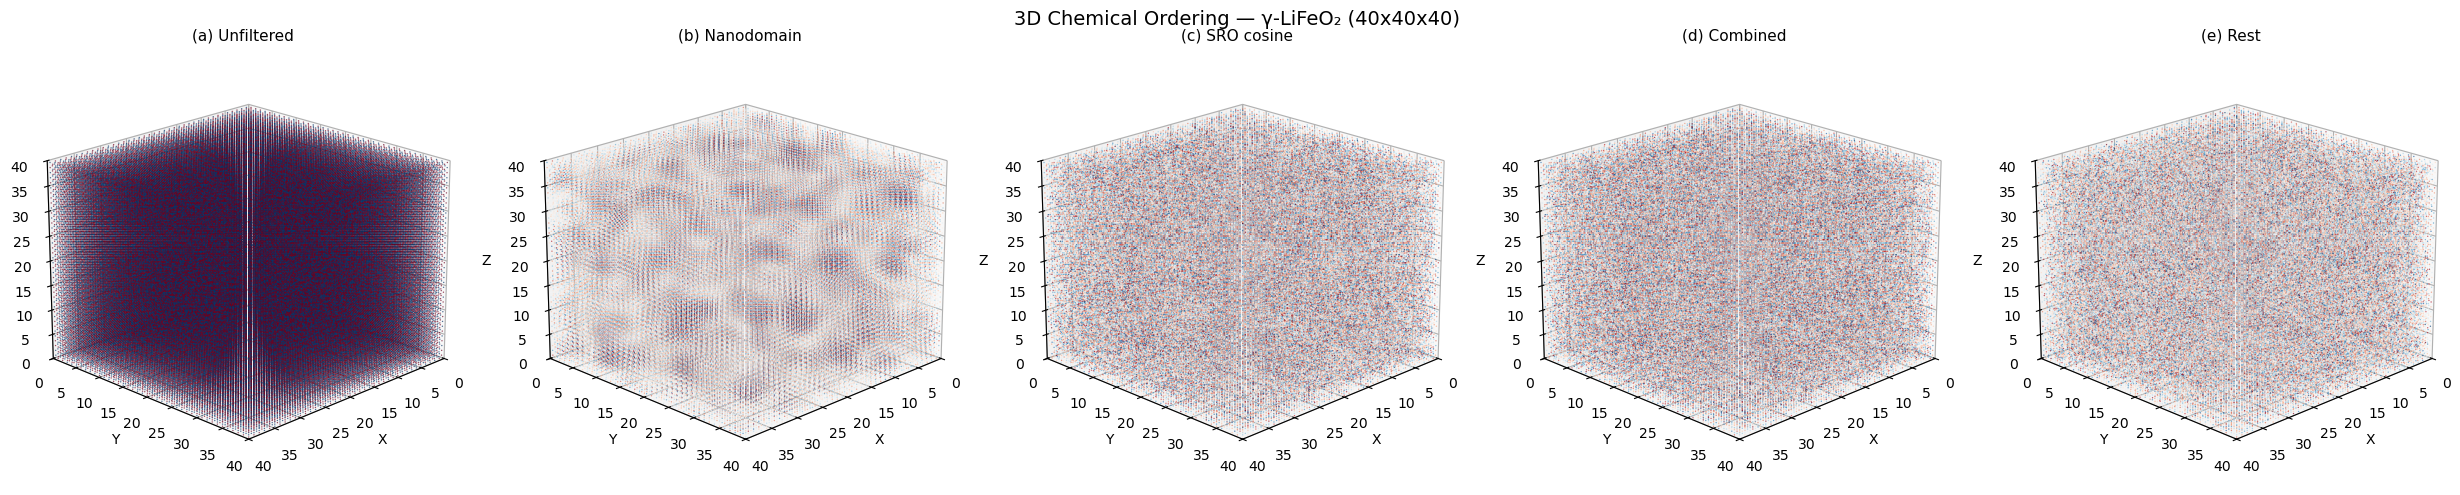

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

titles = {
    "all": "(a) Unfiltered",
    "spheres": "(b) Nanodomain",
    "cosine": "(c) SRO cosine",
    "combined": "(d) Combined",
    "rest": "(e) Rest",
}

fig = plt.figure(figsize=(5 * len(TAGS), 5))
for col, tag in enumerate(TAGS):
    ax = fig.add_subplot(1, len(TAGS), col + 1, projection="3d")
    d = results[tag]
    re = d["re"]

    # Per-tag vmax for good contrast
    vmax = np.percentile(np.abs(re), 99) if len(re) > 0 else 1.0
    if vmax < 1e-12:
        vmax = 1.0

    sc = ax.scatter(
        d["cx"], d["cy"], d["cz"],
        c=re, s=1,
        cmap="RdBu_r", vmin=-vmax, vmax=vmax,
        alpha=0.7, edgecolors="none", depthshade=True,
    )
    ax.set_xlim(0, SC_DIM)
    ax.set_ylim(0, SC_DIM)
    ax.set_zlim(0, SC_DIM)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(titles[tag], fontsize=11)
    ax.view_init(elev=20, azim=45)

fig.suptitle(
    "3D Chemical Ordering \u2014 \u03b3-LiFeO\u2082 (%dx%dx%d)" % (SC_DIM, SC_DIM, SC_DIM),
    fontsize=14,
)
plt.tight_layout()
plt.show()

## 6. Coordination Analysis (Rocksalt Topology)

In rocksalt, each O has exactly **6 nearest-neighbour cations** at $\pm a/2$ along
each axis. The SRO constraint requires 3 Li + 3 Fe around every O (charge neutrality).

We read **all atoms** from the rmc6f structure file to get ground-truth Li/Fe labels
for all 32000 cation sites (the MOSAIC output only contains ~16000 configured points).

**Analysis:**
1. **Ground-truth coordination histogram** \u2014 Fe:Li counts from actual element labels.
   Expected: ~70% have 3:3, rest mostly 4:2 and 2:4.
2. **MOSAIC intensity stratified by coordination** \u2014 for each mask, we report
   the average I and Im(I) around O sites, broken down by their actual
   coordination type. Im(I) \u2248 0 is a sanity check.

In [12]:
# --- Coordination analysis ---
structure_path = EXAMPLE_DIR / STRUCTURE_FILE

atom_els, atom_frac = [], []
with open(structure_path) as f:
    in_atoms = False
    for line in f:
        if line.strip().startswith("Atoms:"):
            in_atoms = True
            continue
        if not in_atoms:
            continue
        parts = line.split()
        if len(parts) < 6:
            continue
        atom_els.append(parts[1])
        atom_frac.append((float(parts[3]), float(parts[4]), float(parts[5])))

atom_els = np.array(atom_els)
atom_frac = np.array(atom_frac)

n_half = SC_DIM * 2
gx = np.round(atom_frac[:, 0] * SC_DIM * 2).astype(int) % n_half
gy = np.round(atom_frac[:, 1] * SC_DIM * 2).astype(int) % n_half
gz = np.round(atom_frac[:, 2] * SC_DIM * 2).astype(int) % n_half

el_grid = np.full((n_half, n_half, n_half), "", dtype="U2")
for i in range(len(atom_els)):
    el_grid[gx[i], gy[i], gz[i]] = atom_els[i]

is_O = atom_els == "O"
oi, oj, ok = gx[is_O], gy[is_O], gz[is_O]
n_o = len(oi)

NN_OFFSETS = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]
nn_i = np.stack([(oi + di) % n_half for di, _, _ in NN_OFFSETS])
nn_j = np.stack([(oj + dj) % n_half for _, dj, _ in NN_OFFSETS])
nn_k = np.stack([(ok + dk) % n_half for _, _, dk in NN_OFFSETS])

nn_el = el_grid[nn_i, nn_j, nn_k]
fe_count = np.sum(nn_el == "Fe", axis=0)
li_count = np.sum(nn_el == "Li", axis=0)

print("=== Ground-truth coordination (%d O) ===" % n_o)
for nfe in range(7):
    nli = 6 - nfe
    cnt = int(np.sum((fe_count == nfe) & (li_count == nli)))
    pct = 100.0 * cnt / n_o
    bar = "#" * int(pct / 2)
    print("  Fe:%d Li:%d  %6d  (%5.1f%%)  %s" % (nfe, nli, cnt, pct, bar))

# Cation mask on grid
is_cat_grid = (el_grid == "Li") | (el_grid == "Fe")

# === Per mask ===
for tag in TAGS:
    d = results[tag]
    i_grid = np.full((n_half, n_half, n_half), np.nan)
    mx = np.round(d["cx"] * 2).astype(int) % n_half
    my = np.round(d["cy"] * 2).astype(int) % n_half
    mz = np.round(d["cz"] * 2).astype(int) % n_half
    for idx in range(len(mx)):
        i_grid[mx[idx], my[idx], mz[idx]] = d["re"][idx]

    n_data = int(np.sum(is_cat_grid & ~np.isnan(i_grid)))
    print("\n========== [%s] (%d / %d cations with data) ==========" % (
        tag, n_data, int(np.sum(is_cat_grid))))

    # --- Per-cation I distribution by element ---
    cat_I = i_grid[is_cat_grid]
    cat_el = el_grid[is_cat_grid]
    has = ~np.isnan(cat_I)
    fe_I = cat_I[has & (cat_el[has] == "Fe")] if has.sum() > 0 else np.array([])
    li_I = cat_I[has & (cat_el[has] == "Li")] if has.sum() > 0 else np.array([])

    # Handle the boolean indexing properly
    fe_mask = has.copy()
    li_mask = has.copy()
    fe_mask[has] = cat_el[has] == "Fe"
    li_mask[has] = cat_el[has] == "Li"
    fe_I = cat_I[fe_mask]
    li_I = cat_I[li_mask]

    print("  Fe cations: n=%d  <I>=%.4f  std=%.4f  frac>0=%.1f%%" % (
        len(fe_I), np.mean(fe_I) if len(fe_I)>0 else 0,
        np.std(fe_I) if len(fe_I)>0 else 0,
        100*np.mean(fe_I > 0) if len(fe_I)>0 else 0))
    print("  Li cations: n=%d  <I>=%.4f  std=%.4f  frac<0=%.1f%%" % (
        len(li_I), np.mean(li_I) if len(li_I)>0 else 0,
        np.std(li_I) if len(li_I)>0 else 0,
        100*np.mean(li_I < 0) if len(li_I)>0 else 0))
    if len(fe_I)>0 and len(li_I)>0:
        acc = (np.sum(fe_I > 0) + np.sum(li_I < 0)) / (len(fe_I) + len(li_I)) * 100
        print("  Sign accuracy: %.1f%%" % acc)

    # --- Coordination: A'/A'' from sign(I) around O ---
    nn_I = i_grid[nn_i, nn_j, nn_k]
    nn_has = ~np.isnan(nn_I)
    nn_data = nn_has.sum(axis=0)
    ap_count = np.sum(nn_has & (nn_I > 0), axis=0)
    app_count = np.sum(nn_has & (nn_I < 0), axis=0)

    has_all = nn_data == 6
    n6 = int(has_all.sum())

    if n6 > 0:
        print("\n  Coordination around O (%d O with 6/6 NN):" % n6)
        print("  %9s %6s %6s   |  %9s %6s %6s" % (
            "A'/A''", "count", "%", "Fe/Li", "count", "%"))
        print("  " + "-" * 58)
        for n_ap in range(7):
            n_app_v = 6 - n_ap
            f_cnt = int(np.sum((ap_count == n_ap) & (app_count == n_app_v) & has_all))
            f_pct = 100.0 * f_cnt / n6
            gt_cnt = int(np.sum((fe_count == n_ap) & (li_count == n_app_v) & has_all))
            gt_pct = 100.0 * gt_cnt / n6
            print("  A':%d A'':%d %6d %5.1f%%   |  Fe:%d Li:%d %6d %5.1f%%" % (
                n_ap, n_app_v, f_cnt, f_pct, n_ap, n_app_v, gt_cnt, gt_pct))

    # --- <I> around O by coordination ---
    nn_I_z = np.where(nn_has, nn_I, 0.0)
    i_avg = np.where(nn_data > 0, nn_I_z.sum(axis=0) / nn_data, np.nan)
    print("\n  <I> around O by coordination:")
    for nfe in range(7):
        nli = 6 - nfe
        sel = (fe_count == nfe) & (li_count == nli) & (nn_data > 0)
        cnt = int(np.sum(sel))
        if cnt > 0:
            vals = i_avg[sel]
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                print("    Fe:%d Li:%d  n=%5d  <I>=%9.5f  std=%8.5f" % (
                    nfe, nli, cnt, np.mean(vals), np.std(vals)))

=== Ground-truth coordination (256000 O) ===
  Fe:0 Li:6      76  (  0.0%)  
  Fe:1 Li:5    1659  (  0.6%)  
  Fe:2 Li:4   46043  ( 18.0%)  ########
  Fe:3 Li:3  160313  ( 62.6%)  ###############################
  Fe:4 Li:2   46175  ( 18.0%)  #########
  Fe:5 Li:1    1674  (  0.7%)  
  Fe:6 Li:0      60  (  0.0%)  

========== [all] (256000 / 256000 cations with data) ==========
  Fe cations: n=128019  <I>=5.7504  std=0.0559  frac>0=100.0%
  Li cations: n=127981  <I>=-5.7521  std=0.0554  frac<0=100.0%
  Sign accuracy: 100.0%

  Coordination around O (256000 O with 6/6 NN):
     A'/A''  count      %   |      Fe/Li  count      %
  ----------------------------------------------------------
  A':0 A'':6     76   0.0%   |  Fe:0 Li:6     76   0.0%
  A':1 A'':5   1659   0.6%   |  Fe:1 Li:5   1659   0.6%
  A':2 A'':4  46043  18.0%   |  Fe:2 Li:4  46043  18.0%
  A':3 A'':3 160313  62.6%   |  Fe:3 Li:3 160313  62.6%
  A':4 A'':2  46175  18.0%   |  Fe:4 Li:2  46175  18.0%
  A':5 A'':1   1674   0.

## 6. Linearity Check

1. $I_{\text{combined}} + I_{\text{rest}} = I_{\text{all}}$
2. $I_{\text{spheres}} + I_{\text{cosine}} = I_{\text{combined}}$

In [13]:
r = results

d1_re = (r["combined"]["re"] + r["rest"]["re"]) - r["all"]["re"]
d1_im = (r["combined"]["im"] + r["rest"]["im"]) - r["all"]["im"]
d1_mag = np.sqrt(d1_re**2 + d1_im**2)

d2_re = (r["spheres"]["re"] + r["cosine"]["re"]) - r["combined"]["re"]
d2_im = (r["spheres"]["im"] + r["cosine"]["im"]) - r["combined"]["im"]
d2_mag = np.sqrt(d2_re**2 + d2_im**2)

full_mag = np.sqrt(r["all"]["re"]**2 + r["all"]["im"]**2)
rms_full = np.sqrt(np.mean(full_mag**2))
comb_mag = np.sqrt(r["combined"]["re"]**2 + r["combined"]["im"]**2)
rms_comb = np.sqrt(np.mean(comb_mag**2))

print("Linearity verification:")
print(f"  RMS |I_all|      : {rms_full:.6f}")
print(f"  RMS |I_combined| : {rms_comb:.6f}")
print()
print("  Check 1: combined + rest = all")
print(f"    RMS |residual|   : {np.sqrt(np.mean(d1_mag**2)):.2e}")
print(f"    Relative error   : {np.sqrt(np.mean(d1_mag**2)) / rms_full:.2e}")
print()
print("  Check 2: spheres + cosine = combined")
print(f"    RMS |residual|   : {np.sqrt(np.mean(d2_mag**2)):.2e}")
print(f"    Relative error   : {np.sqrt(np.mean(d2_mag**2)) / rms_comb:.2e}")

Linearity verification:
  RMS |I_all|      : 5.751494
  RMS |I_combined| : 4.514415

  Check 1: combined + rest = all
    RMS |residual|   : 5.74e-09
    Relative error   : 9.98e-10

  Check 2: spheres + cosine = combined
    RMS |residual|   : 5.82e-09
    Relative error   : 1.29e-09


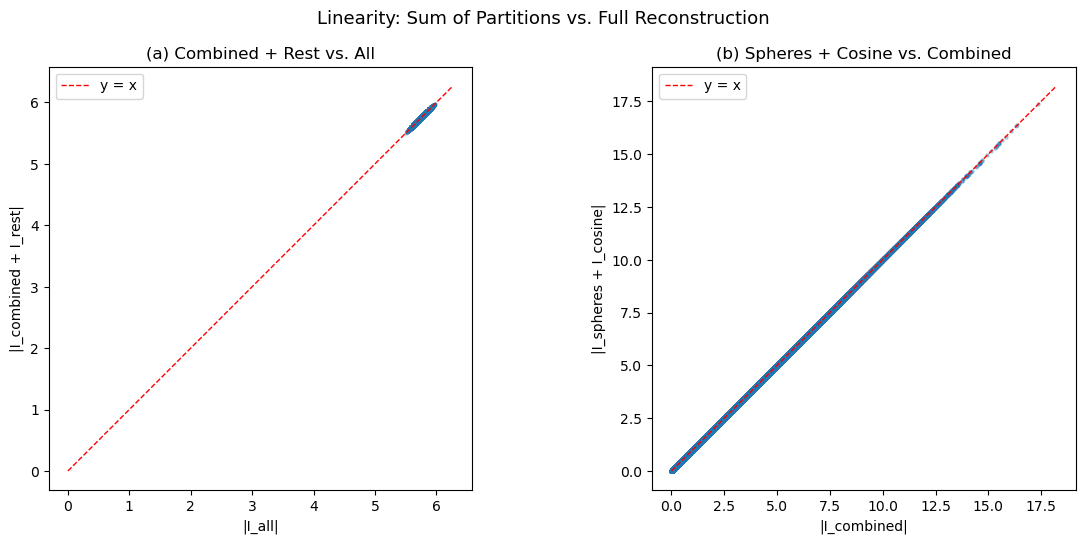

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

ax = axes[0]
s1 = np.sqrt((r["combined"]["re"] + r["rest"]["re"])**2 + (r["combined"]["im"] + r["rest"]["im"])**2)
ax.scatter(full_mag, s1, s=5, alpha=0.3)
lims = [0, max(full_mag.max(), s1.max()) * 1.05]
ax.plot(lims, lims, "r--", lw=1, label="y = x")
ax.set_xlabel("|I_all|"); ax.set_ylabel("|I_combined + I_rest|")
ax.set_title("(a) Combined + Rest vs. All"); ax.set_aspect("equal"); ax.legend()

ax = axes[1]
s2 = np.sqrt((r["spheres"]["re"] + r["cosine"]["re"])**2 + (r["spheres"]["im"] + r["cosine"]["im"])**2)
ax.scatter(comb_mag, s2, s=5, alpha=0.3)
lims2 = [0, max(comb_mag.max(), s2.max()) * 1.05]
ax.plot(lims2, lims2, "r--", lw=1, label="y = x")
ax.set_xlabel("|I_combined|"); ax.set_ylabel("|I_spheres + I_cosine|")
ax.set_title("(b) Spheres + Cosine vs. Combined"); ax.set_aspect("equal"); ax.legend()

fig.suptitle("Linearity: Sum of Partitions vs. Full Reconstruction", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Summary

This notebook demonstrated MOSAIC for **3D chemical SRO** in γ-LiFeO₂ (40x40x40):

1. **Structure** — 40×40×40 supercell (~512,000 atoms) with competing Li/Fe ordering
2. **Five MOSAIC runs** — unfiltered, spheres, cosine, combined, rest
3. **(001) slices** — nanodomain clusters (spheres) and percolating SRO matrix (cosine) cleanly separated
4. **Linearity** — $I_{\text{combined}} + I_{\text{rest}} = I_{\text{all}}$ and $I_{\text{spheres}} + I_{\text{cosine}} = I_{\text{combined}}$

In [15]:
# --- Cleanup (optional) ---
# for tag in TAGS:
#     for p in [
#         EXAMPLE_DIR / f"output_demo_lifeo2_40x40x40_{tag}",
#         EXAMPLE_DIR / f"input_parameters_demo_40x40x40_{tag}.json",
#         EXAMPLE_DIR / f"run_parameters_demo_40x40x40_{tag}.json",
#     ]:
#         if p.is_dir(): shutil.rmtree(p); print(f"Removed {p}")
#         elif p.is_file(): p.unlink(); print(f"Removed {p}")